# ✅ Solutions — Module 2 — Probability Foundations

Worked solutions for every exercise of this module. **Try the exercise yourself first** — you learn statistics by *doing* it. Each solution ends with a short interpretation, because in real projects the numbers are only half of the answer.

*Every exercise is self-contained: run the setup cell below, then jump to any exercise.*

In [1]:
# --- Course setup (identical in every module) ---
import warnings; warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({"figure.figsize": (9, 4.2), "figure.dpi": 90, "axes.titleweight": "bold",
                     "axes.spines.top": False, "axes.spines.right": False})
C = sns.color_palette("deep")      # C[0] blue, C[1] orange, C[2] green, C[3] red, C[4] purple
rng = np.random.default_rng(42)    # seeded generator => reproducible results

### ✍️ Exercise 2.1 — *Bayes' theorem*: Build a tiny spam filter (email security)

You have 10,000 labelled e-mails with two binary features: does the mail contain the word **"free"**, does it contain the word **"meeting"**?

**Tasks**
1. Estimate from the data: $P(\text{spam})$, $P(\text{free} \mid \text{spam})$, $P(\text{free} \mid \text{ham})$.
2. Use **Bayes' theorem** to compute $P(\text{spam} \mid \text{free})$. Verify your result by computing the conditional relative frequency directly.
3. A mail contains *both* "free" and "meeting". Assuming the words are conditionally independent given the class (*naive Bayes*), compute $P(\text{spam} \mid \text{free}, \text{meeting})$. Compare with the direct frequency. What does the word "meeting" do to the evidence?
4. Are "free" and "meeting" independent in the *whole* data set? Check $P(A \cap B)$ vs $P(A)P(B)$ and explain.

In [2]:
g = np.random.default_rng(201)
spam = g.random(10_000) < 0.40
mails = pd.DataFrame({"spam": spam,
                      "free":    np.where(spam, g.random(10_000) < .30, g.random(10_000) < .02),
                      "meeting": np.where(spam, g.random(10_000) < .01, g.random(10_000) < .15)})
mails.head()

,spam,free,meeting
0,False,False,False
1,False,False,False
2,False,False,False
3,False,False,False
4,False,False,False


P(spam) = 0.407,  P(free|spam) = 0.292,  P(free|ham) = 0.020

2) Bayes : P(spam | free) = 0.910      direct frequency: 0.910
3) naive Bayes : P(spam | free, meeting) = 0.438      direct frequency: 0.548  (only 31 such mails!)
4) P(free ∩ meeting) = 0.0031   vs   P(free)·P(meeting) = 0.0115  -> not independent overall


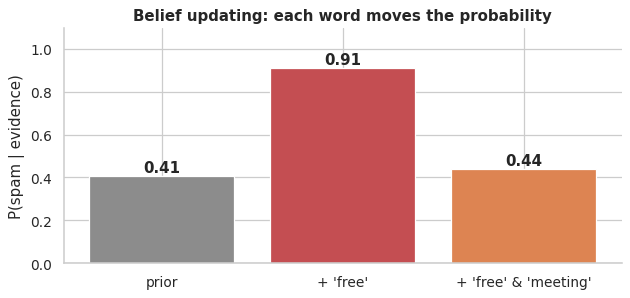

In [3]:
p_spam = mails.spam.mean()
p_free_s, p_free_h = mails[mails.spam].free.mean(), mails[~mails.spam].free.mean()
p_meet_s, p_meet_h = mails[mails.spam].meeting.mean(), mails[~mails.spam].meeting.mean()
print(f"P(spam) = {p_spam:.3f},  P(free|spam) = {p_free_s:.3f},  P(free|ham) = {p_free_h:.3f}")

bayes = p_free_s * p_spam / (p_free_s * p_spam + p_free_h * (1 - p_spam))
print(f"\n2) Bayes : P(spam | free) = {bayes:.3f}      direct frequency: {mails[mails.free].spam.mean():.3f}")

num = p_spam * p_free_s * p_meet_s; den = num + (1 - p_spam) * p_free_h * p_meet_h
both = mails[mails.free & mails.meeting]
print(f"3) naive Bayes : P(spam | free, meeting) = {num / den:.3f}      direct frequency: {both.spam.mean():.3f}  (only {len(both)} such mails!)")

pA, pB, pAB = mails.free.mean(), mails.meeting.mean(), (mails.free & mails.meeting).mean()
print(f"4) P(free ∩ meeting) = {pAB:.4f}   vs   P(free)·P(meeting) = {pA * pB:.4f}  -> not independent overall")

fig, ax = plt.subplots(figsize=(8, 3.4))
steps = ["prior", "+ 'free'", "+ 'free' & 'meeting'"]; vals = [p_spam, bayes, num / den]
ax.bar(steps, vals, color=[C[7], C[3], C[1]]); [ax.text(i, v + .02, f"{v:.2f}", ha="center", fontweight="bold") for i, v in enumerate(vals)]
ax.set(ylim=(0, 1.1), ylabel="P(spam | evidence)", title="Belief updating: each word moves the probability"); plt.show()

**Interpretation.** "free" is 15 times more likely in spam than in ham (likelihood ratio ≈ 0.30/0.02), which lifts the spam probability from the 40 % base rate to ≈ 90 %. "meeting" is evidence *against* spam (likelihood ratio ≈ 0.01/0.15 = 1/15) and almost exactly cancels "free" — the posterior falls back to roughly the prior.

The direct frequency for the two-word case rests on a few dozen mails and is therefore noisy; naive Bayes gets a stable estimate by *combining* well-estimated single-word probabilities. That is why it works so well with thousands of words.

Task 4 is subtle: the words are independent *within* each class (that is how the data was generated), but **not overall** — "free" signals spam, and spam rarely contains "meeting", so the words are negatively associated marginally. *Conditional independence does not imply independence.*

### ✍️ Exercise 2.2 — *Probability rules*: How reliable is the server rack? (Reliability engineering)

A small data-centre rack works if **all three subsystems** work during a year:

* **Power:** two redundant power supplies (rack works if *at least one* works); each survives the year with probability 0.95.
* **Network:** a single switch, survival probability 0.99.
* **Storage:** RAID with three disks, works if *at least two of three* disks survive; each disk survives with probability 0.90.

Assume all components fail independently.

**Tasks**
1. Compute the reliability of each subsystem and of the whole rack analytically (complement + multiplication rule).
2. Verify by simulating 1,000,000 rack-years.
3. You have budget for one upgrade: (a) a third power supply, (b) a second redundant switch, (c) better disks (0.97 each). Which one improves rack reliability the most?
4. Why might the independence assumption be dangerously optimistic here?

power 0.9975 · network 0.9900 · storage 0.9720  =>  rack reliability 0.9599
simulation: 0.9600


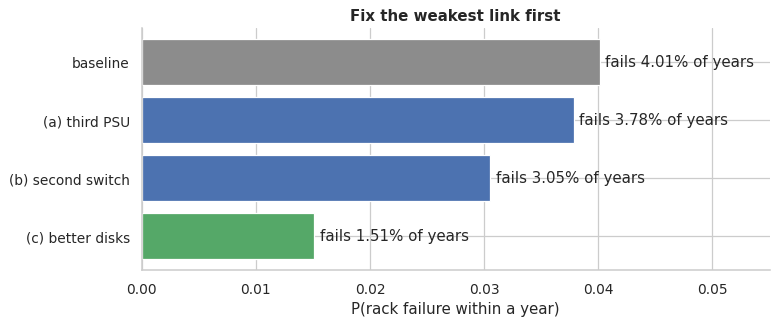

In [4]:
def rack(p_psu=.95, n_psu=2, p_sw=.99, n_sw=1, p_disk=.90):
    power   = 1 - (1 - p_psu) ** n_psu                       # complement: fails only if ALL supplies fail
    network = 1 - (1 - p_sw) ** n_sw
    storage = p_disk ** 3 + 3 * p_disk ** 2 * (1 - p_disk)   # all three OR exactly two of three survive
    return power, network, storage, power * network * storage

pw, nw, st, total = rack()
print(f"power {pw:.4f} · network {nw:.4f} · storage {st:.4f}  =>  rack reliability {total:.4f}")

g = np.random.default_rng(1); N = 1_000_000
ok = ((g.random((N, 2)) < .95).any(axis=1) & (g.random(N) < .99) & ((g.random((N, 3)) < .90).sum(axis=1) >= 2))
print(f"simulation: {ok.mean():.4f}")

options = {"baseline": rack()[3], "(a) third PSU": rack(n_psu=3)[3], "(b) second switch": rack(n_sw=2)[3], "(c) better disks": rack(p_disk=.97)[3]}
fig, ax = plt.subplots(figsize=(9, 3.5))
ax.barh(list(options), [1 - v for v in options.values()], color=[C[7], C[0], C[0], C[2]])
for i, v in enumerate(options.values()): ax.text(1 - v + .0005, i, f"fails {1 - v:.2%} of years", va="center")
ax.set(xlabel="P(rack failure within a year)", title="Fix the weakest link first", xlim=(0, .055)); ax.invert_yaxis(); plt.show()

**Interpretation.** Rack reliability is ≈ 0.960. Redundancy makes the power subsystem very reliable (0.9975) — a third supply adds almost nothing. The **weakest link is storage (0.972)**, so better disks cut the failure probability the most (from ≈ 4.0 % to ≈ 1.5 %), followed by the second switch.

**Independence caveat:** components in one rack share a room, a power line, a firmware version and a production batch. A cooling failure or a power surge kills several components at once (*common-cause failure*), so real-world redundancy is worth less than $1-(1-p)^n$ suggests. This is the same mistake that made bundles of "independent" mortgages look safe in 2008.

### ✍️ Exercise 2.3 — *Base rates*: Why does the fraud team drown in false alarms? (Banking)

A bank processes 1,000,000 card transactions per day; **0.2 %** are fraudulent. A new ML model flags **98 %** of fraudulent transactions (sensitivity) and raises a false alarm on **1 %** of legitimate ones.

**Tasks**
1. Of all flagged transactions, what fraction is actually fraud (PPV)? How many alerts per day must analysts review, and how many of them are real?
2. Draw the PPV as a function of the false-alarm rate (from 0.01 % to 5 %).
3. What false-alarm rate is needed so that at least every second alert is real fraud?
4. The flagged transactions are sent through a **second, independent** check with the same error rates. What is the PPV after two positive flags?

1) alerts/day = 11,940  (real fraud: 1,960, false alarms: 9,980)  ->  PPV = 16.4%
3) PPV ≥ 50 % needs a false-alarm rate ≤ 0.196%  (specificity ≥ 99.804%)
4) PPV after a second independent positive check: 95.1%   (yesterday's posterior is today's prior)


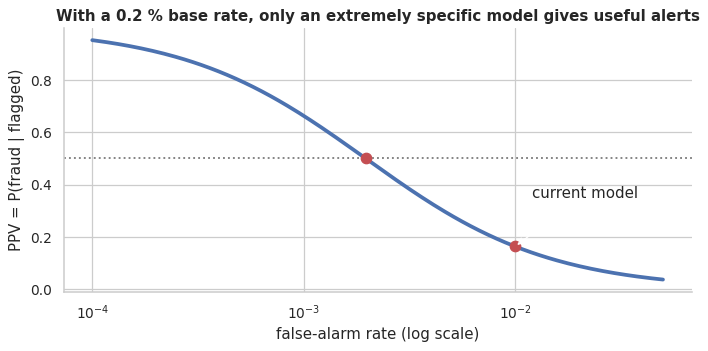

In [5]:
N, prev, sens, fpr = 1_000_000, .002, .98, .01
ppv = lambda prior, fpr=fpr: sens * prior / (sens * prior + fpr * (1 - prior))
tp, fp = N * prev * sens, N * (1 - prev) * fpr
print(f"1) alerts/day = {tp + fp:,.0f}  (real fraud: {tp:,.0f}, false alarms: {fp:,.0f})  ->  PPV = {ppv(prev):.1%}")
fpr_needed = sens * prev / (1 - prev)                       # solve PPV = 0.5 for the false-alarm rate
print(f"3) PPV ≥ 50 % needs a false-alarm rate ≤ {fpr_needed:.3%}  (specificity ≥ {1 - fpr_needed:.3%})")
print(f"4) PPV after a second independent positive check: {ppv(ppv(prev)):.1%}   (yesterday's posterior is today's prior)")

grid = np.logspace(-4, np.log10(.05), 200)
fig, ax = plt.subplots(figsize=(9, 3.8))
ax.plot(grid, [ppv(prev, f) for f in grid], lw=3, color=C[0])
ax.scatter([fpr, fpr_needed], [ppv(prev), .5], color=C[3], zorder=3, s=70)
ax.annotate("current model", (fpr, ppv(prev)), xytext=(.012, .35), arrowprops=dict(arrowstyle="->")); ax.axhline(.5, color="grey", ls=":")
ax.set(xscale="log", xlabel="false-alarm rate (log scale)", ylabel="PPV = P(fraud | flagged)", title="With a 0.2 % base rate, only an extremely specific model gives useful alerts"); plt.show()

**Interpretation.** The model sounds excellent (98 % / 99 %), yet only about **one alert in six** is real: ≈ 12,000 alerts per day, of which ≈ 10,000 are false. With a 0.2 % base rate the false-alarm rate must fall below ≈ 0.2 % before half of the alerts are genuine — for rare events **specificity matters far more than sensitivity**. Chaining two independent checks multiplies the evidence and lifts the PPV to ≈ 95 %; this is exactly why screening programmes use a cheap first test followed by a confirmatory test.

### ✍️ Exercise 2.4 — *Expectation & variance*: Pricing an extended warranty (Retail / insurance)

An electronics retailer sells a 2-year extended warranty for **€89** on a €600 laptop. Historical claim data per laptop:

| Event | no claim | minor repair | major repair | total loss |
|---|---|---|---|---|
| cost to retailer | €0 | €120 | €350 | €600 |
| probability | 0.88 | 0.08 | 0.03 | 0.01 |

**Tasks**
1. Compute the expected claim cost and its standard deviation per warranty. What is the retailer's expected profit per warranty?
2. The retailer sells $n$ warranties (independent laptops). Give mean and standard deviation of the **total** profit for $n = 1,\ 100,\ 10{,}000$. How does the *relative* risk (std / mean) change with $n$?
3. Simulate the total profit for $n = 100$ and $n = 10{,}000$ (20,000 repetitions each) and plot both distributions of *profit per warranty*. Estimate P(loss) for both.
4. The customer's expected "loss" from buying is the retailer's expected profit. Can buying still be rational?

1) E[claim] = 26.10 €,  SD[claim] = 88.01 €,  expected profit per warranty = 62.90 €

2) n =      1: total profit         63 € ±       88 €   relative risk SD/mean = 1.399
2) n =    100: total profit      6,290 € ±      880 €   relative risk SD/mean = 0.140
2) n = 10,000: total profit    629,000 € ±    8,801 €   relative risk SD/mean = 0.014


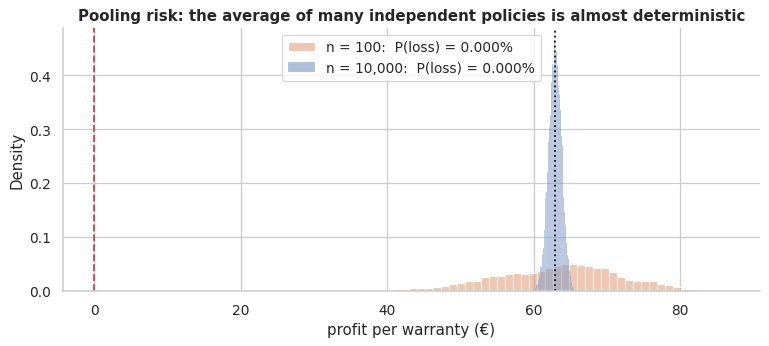

In [6]:
cost = np.array([0, 120, 350, 600.]); prob = np.array([.88, .08, .03, .01]); price = 89
mu = (cost * prob).sum(); sd = np.sqrt(((cost - mu) ** 2 * prob).sum())
print(f"1) E[claim] = {mu:.2f} €,  SD[claim] = {sd:.2f} €,  expected profit per warranty = {price - mu:.2f} €\n")
for n in [1, 100, 10_000]:
    m, s = n * (price - mu), np.sqrt(n) * sd                # means add, VARIANCES add -> SD grows only with sqrt(n)
    print(f"2) n = {n:>6,}: total profit {m:>10,.0f} € ± {s:>8,.0f} €   relative risk SD/mean = {s / m:.3f}")

g = np.random.default_rng(2); fig, ax = plt.subplots(figsize=(10, 3.8))
for n, col in [(100, C[1]), (10_000, C[0])]:
    claims = g.multinomial(n, prob, size=20_000) @ cost     # total claim cost of n laptops, 20,000 simulated years
    per = price - claims / n
    sns.histplot(per, bins=60, stat="density", ax=ax, color=col, alpha=.45, label=f"n = {n:,}:  P(loss) = {(per < 0).mean():.3%}")
ax.axvline(0, color=C[3], ls="--"); ax.axvline(price - mu, color="k", ls=":")
ax.set(xlabel="profit per warranty (€)", title="Pooling risk: the average of many independent policies is almost deterministic"); ax.legend(); plt.show()

**Interpretation.** The expected claim is only ≈ €26, so the retailer earns ≈ €63 per warranty — a 70 % margin. For a single policy the standard deviation (≈ €88) exceeds the expected profit; for 10,000 policies the *relative* risk has shrunk by a factor of $\sqrt{10{,}000} = 100$ and a loss is practically impossible. **This $\sqrt{n}$ law is the business model of insurance.**

For the customer the purchase has a negative expected value (−€63). It can still be rational for someone who could not absorb a €600 loss (risk aversion: the *utility* of money is not linear). For most buyers of a €600 laptop, however, "self-insuring" is the better deal — which is why consumer organisations advise against such warranties.

### ✍️ Exercise 2.5 — *Monte Carlo*: Will the project meet its deadline? (Project risk management)

A product launch consists of three **sequential** work packages. Experts give optimistic / most likely / pessimistic durations in working days (→ triangular distributions):

| Package | optimistic | most likely | pessimistic |
|---|---|---|---|
| Design | 10 | 14 | 25 |
| Development | 20 | 30 | 55 |
| Testing & certification | 8 | 10 | 20 |

In addition, there is a **20 % chance** that a supplier delivers late, adding a delay uniformly distributed between 5 and 15 days. The contractual deadline is **65 working days**.

**Tasks**
1. The "naive plan" adds the most-likely values. What does it predict?
2. Simulate 100,000 project runs. Plot the distribution of the total duration and mark the naive plan and the deadline.
3. Estimate P(deadline missed), the expected duration and the 80 % / 95 % quantiles ("P80 / P95 dates").
4. What deadline should the project manager commit to if she wants to be 90 % sure?

naive plan: 54 days | simulated mean: 66.0 days | P(naive plan is met) = 9.2%
P(deadline of 65 days missed) = 51.1%
P80 = 74 days, P90 = 79 days, P95 = 83 days


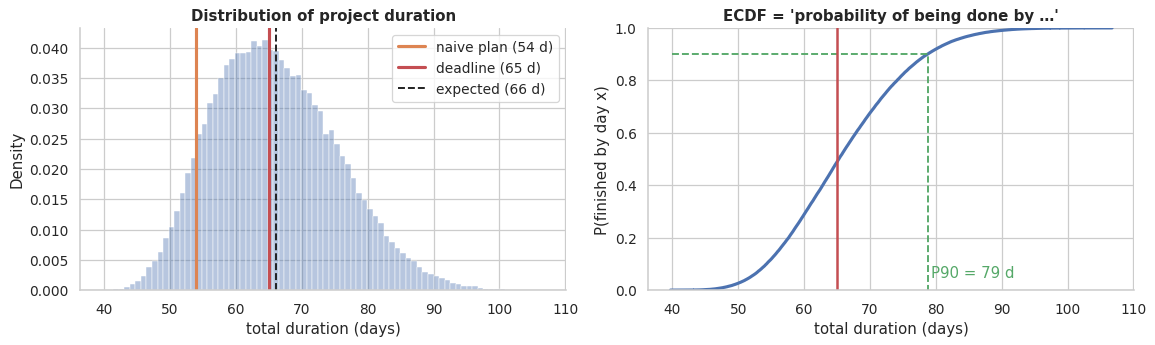

In [7]:
g = np.random.default_rng(3); N = 100_000
design, dev, test = g.triangular(10, 14, 25, N), g.triangular(20, 30, 55, N), g.triangular(8, 10, 20, N)
delay = np.where(g.random(N) < .20, g.uniform(5, 15, N), 0)
total = design + dev + test + delay
naive, deadline = 14 + 30 + 10, 65
p80, p90, p95 = np.quantile(total, [.8, .9, .95])
print(f"naive plan: {naive} days | simulated mean: {total.mean():.1f} days | P(naive plan is met) = {(total <= naive).mean():.1%}")
print(f"P(deadline of {deadline} days missed) = {(total > deadline).mean():.1%}")
print(f"P80 = {p80:.0f} days, P90 = {p90:.0f} days, P95 = {p95:.0f} days")

fig, (a1, a2) = plt.subplots(1, 2, figsize=(13, 4))
sns.histplot(total, bins=80, stat="density", ax=a1, color=C[0], alpha=.4)
a1.axvline(naive, color=C[1], lw=2.5, label=f"naive plan ({naive} d)"); a1.axvline(deadline, color=C[3], lw=2.5, label=f"deadline ({deadline} d)")
a1.axvline(total.mean(), color="k", ls="--", label=f"expected ({total.mean():.0f} d)"); a1.set(xlabel="total duration (days)", title="Distribution of project duration"); a1.legend()
sns.ecdfplot(total, ax=a2, lw=2.5, color=C[0]); a2.plot([40, p90, p90], [.9, .9, 0], color=C[2], ls="--"); a2.text(p90 + .5, .05, f"P90 = {p90:.0f} d", color=C[2])
a2.axvline(deadline, color=C[3], lw=2); a2.set(xlabel="total duration (days)", ylabel="P(finished by day x)", title="ECDF = 'probability of being done by …'"); plt.tight_layout(); plt.show()

**Interpretation.** The naive plan (54 days) is met in fewer than 10 % of all runs: every task is right-skewed (things can go much more wrong than right), so the *expected* duration (≈ 66 days) lies far above the sum of the "most likely" values — **the sum of the modes is not the mode of the sum**. The 65-day deadline is missed in roughly half of all simulated projects; a commitment with 90 % confidence needs ≈ 79 days.

This is how professional schedule-risk analysis works (PERT / Monte Carlo): communicate **P50 / P80 / P90 dates**, never a single number.